# Progetto 3


1) Data Exploration and Preprocessing

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [38]:
data = load_wine()

X,y = data.data, data.target

df = pd.DataFrame(X, columns = data.feature_names)
df["target"] = y
print(df.dtypes)
print(df.head())

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object
   alcohol  malic_acid   ash  ...  od280/od315_of_diluted_wines  proline  target
0    14.23        1.71  2.43  ...                          3.92   1065.0       0
1    13.20        1.78  2.14  ...                          3.40   1050.0       0
2    13.16        2.36  2.67  ...                          3.17   1185.0       0
3    14.37        1.95  2.50  ...                          3.45   1480.0       0
4    13.24        2.5

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. Data Dimensionality and Reduction

In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

3. Addestramento e Valutazione

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel="linear")

knn.fit(X_pca, y)
svm.fit(X_pca, y)

y_pred_knn = knn.predict(X_pca)
y_pred_svm = svm.predict(X_pca)

acc_knn = ((y == y_pred_knn).sum())/(len(y))*100
acc_svm = ((y == y_pred_svm).sum())/(len(y))*100

print(f"ACCURACY KNN: {acc_knn:.2f}%")
print(f"ACCURACY SVM: {acc_svm:.2f}%")



ACCURACY KNN: 96.63%
ACCURACY SVM: 97.19%


4. Analisi e Visulazzazione

Text(0.5, 1.0, 'SVM (linear) Classification')

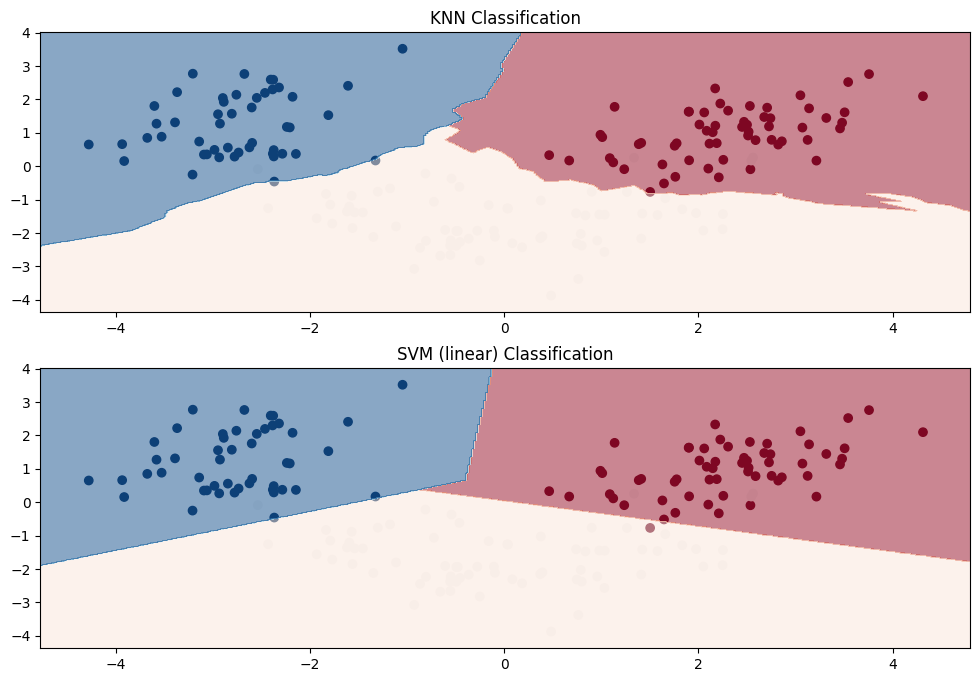

In [55]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize = (12,8))

x_min, x_max = X_pca[:,0].min() - 0.5, X_pca[:,0].max() + 0.5
y_min, y_max = X_pca[:,1].min() - 0.5, X_pca[:,1].max() + 0.5
xx,yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

ax[0].scatter(X_pca[:,0], X_pca[:,1], c = y, cmap = plt.cm.RdBu)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax[0].contourf(xx,yy, Z, alpha = 0.5, cmap = plt.cm.RdBu)
ax[0].set_xlim(xx.min(), xx.max())
ax[0].set_ylim(yy.min(), yy.max())
ax[0].set_title("KNN Classification")

ax[1].scatter(X_pca[:,0], X_pca[:,1], c = y, cmap = plt.cm.RdBu)
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax[1].contourf(xx,yy,Z,alpha = 0.5, cmap = plt.cm.RdBu)
ax[1].set_xlim(xx.min(), xx.max())
ax[1].set_ylim(yy.min(), yy.max())
ax[1].set_title("SVM (linear) Classification")